ARTERIAL STENOSIS DETECTION - COMPLETE PRE-PROCESSING PIPELINE
==========================================================

This notebook handles the preprocessing pipeline for three datasets:

1. **CADICA Dataset**: Coronary angiography images with severity labels
2. **NHANES Dataset**: Clinical and demographic data in XPT format

### Objectives:
- Preprocess imaging data (resize, normalize, ImageNet standardization)
- Handle video frame extraction
- Encode categorical labels (3 classes only)
- Process clinical tabular data (XPT → CSV conversion, merging, cleaning)
- Generate visualizations and summary statistics
- Prepare data for downstream machine learning models


## 1. SETUP & IMPORTS


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import glob
from tqdm import tqdm
import warnings
import pickle
warnings.filterwarnings('ignore')

# Image processing
import cv2
from PIL import Image
import imageio

# Statistical and ML preprocessing
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# -------- NEW: NHANES ML MODEL LIBRARIES --------
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# XGBoost (preferred clinical model)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("Warning: XGBoost not installed. Install with: pip install xgboost")

# -------- NEW: HYPERPARAMETER + OPTIM --------
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

# -------- XPT file reading --------
try:
    import pyreadstat
    XPT_AVAILABLE = True
except ImportError:
    print("Warning: pyreadstat not installed. Install with: pip install pyreadstat")
    XPT_AVAILABLE = False

# Optional: Data augmentation
try:
    import albumentations as A
    AUG_AVAILABLE = True
except ImportError:
    AUG_AVAILABLE = False
    print("Note: albumentations not installed. Augmentation features disabled.")

# PyTorch for deterministic behavior
import torch
import torch.nn as nn
import torch.optim as optim
import random
import hashlib

# -------- NEW: LION OPTIMIZER --------
try:
    from lion_pytorch import Lion
    LION_AVAILABLE = True
except ImportError:
    LION_AVAILABLE = False
    print("Warning: lion-pytorch not installed. Install with: pip install lion-pytorch")

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("✓ All imports successful!")
print(f"Using seed: {SEED}")


✓ All imports successful!
Using seed: 42


## 2. GLOBAL CONFIGURATION


In [2]:
# Directory paths
BASE_DIR = Path.cwd()

ARCHADE_DIR = BASE_DIR / "Stenosis detection"
CADICA_DIR = BASE_DIR / "CADICA"
CADICA_SELECTED_DIR = CADICA_DIR / "CADICA" / "selectedVideos"
NHANES_DIR = BASE_DIR / "NHANES"

# Output directories
PROCESSED_DIR = BASE_DIR / "processed_data"
PROCESSED_ARCHADE_DIR = PROCESSED_DIR / "ARCHADE"
PROCESSED_CADICA_DIR = PROCESSED_DIR / "CADICA"
PROCESSED_NHANES_DIR = PROCESSED_DIR / "NHANES"

# Create output directories
PROCESSED_DIR.mkdir(exist_ok=True)
PROCESSED_ARCHADE_DIR.mkdir(exist_ok=True)
PROCESSED_CADICA_DIR.mkdir(exist_ok=True)
PROCESSED_NHANES_DIR.mkdir(exist_ok=True)

# Image preprocessing parameters
TARGET_SIZE = (224, 224)
GRAYSCALE = False
NORMALIZE = True

# ImageNet normalization constants
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

## 3-CLASS LABEL MAPPING (CRITICAL CHANGE)

In [3]:
# ============================================================
# CADICA – 3-Class Supervised Classification Configuration
# ============================================================

# Class mapping
LABEL_MAPPING = {
    "Normal": 0,
    "Mild": 1,
    "Severe": 2
}

INVERSE_LABEL_MAPPING = {v: k for k, v in LABEL_MAPPING.items()}

# CADICA stenosis category → severity class
CATEGORY_TO_SEVERITY = {
    "p0": "Normal",
    "p0_20": "Normal",

    "p20": "Mild",
    "p20_35": "Mild",
    "p35": "Mild",
    "p35_60": "Mild",
    "p50": "Mild",
    "p0_50": "Mild",
    "p20_50": "Mild",

    "p60": "Severe",
    "p60_100": "Severe",
    "p50_70": "Severe",
    "p50_100": "Severe",
    "p70": "Severe",
    "p70_100": "Severe",
    "p100": "Severe"
}

# Dataset split ratios (patient-level)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
IMG_SIZE=224

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CADICA SUPERVISED CNN CONFIGURATION (OPTION 2)")
print("=" * 70)
print(f"Target image size       : {TARGET_SIZE}")
print(f"Normalization           : ImageNet (training only)")
print(f"Task                    : 3-class severity classification")
print(f"Classes                 : {list(LABEL_MAPPING.keys())}")
print(f"Train / Val / Test split: "
      f"{TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")
print("=" * 70)



CADICA SUPERVISED CNN CONFIGURATION (OPTION 2)
Target image size       : (224, 224)
Normalization           : ImageNet (training only)
Task                    : 3-class severity classification
Classes                 : ['Normal', 'Mild', 'Severe']
Train / Val / Test split: 70% / 15% / 15%


## 3. HELPER FUNCTIONS


In [4]:
def load_image(image_path, target_size=None, grayscale=False, normalize=False):
    """Load and preprocess a single image"""
    try:
        if grayscale:
            img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                return None
            img = np.expand_dims(img, axis=-1)
        else:
            img = cv2.imread(str(image_path))
            if img is None:
                return None
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if target_size:
            img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

        if normalize:
            img = img.astype(np.float32) / 255.0

        return img

    except Exception as e:
        print(f"⚠ Error loading {image_path}: {e}")
        return None

def detect_corrupt_files(file_list, sample_size=100):
    """Detect corrupt image files"""
    corrupt_files = []
    files_to_check = file_list[:sample_size] if sample_size else file_list

    print(f" Checking {len(files_to_check)} files for corruption...")
    for file_path in tqdm(files_to_check, desc="Checking files"):
        img = load_image(file_path, normalize=False)
        if img is None:
            corrupt_files.append(file_path)

    return corrupt_files


def extract_video_frames(video_path, num_frames=10, target_size=None):
    """Extract evenly sampled frames from a video"""
    frames = []
    try:
        cap = cv2.VideoCapture(str(video_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            return frames

        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if target_size:
                frame = cv2.resize(frame, target_size, interpolation=cv2.INTER_AREA)

            frames.append(frame)

        cap.release()

    except Exception as e:
        print(f"⚠ Error extracting frames from {video_path}: {e}")

    return frames

def assign_split_by_patient(patient_id, train_ratio=0.7, val_ratio=0.15):
    """
    Deterministic split assignment based on PATIENT ID
    Prevents patient-level data leakage
    """
    hash_val = int(hashlib.md5(str(patient_id).encode()).hexdigest(), 16) % 100

    if hash_val < train_ratio * 100:
        return "train"
    elif hash_val < (train_ratio + val_ratio) * 100:
        return "val"
    else:
        return "test"

print(" Helper functions defined")


 Helper functions defined


## Class-Conditional Augmentation Strategy

In [5]:
from torchvision import transforms

# ============================================================
# CNN Feature Extractor Transforms (LABEL-AGNOSTIC)
# ============================================================

cnn_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

cnn_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("CNN transforms defined")


CNN transforms defined


In [6]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class CancerImageDataset(Dataset):
    """
    Dataset for CNN feature extraction (NO LABELS).
    Images are loaded from flat directories.
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        # Load all image paths
        self.image_paths = sorted(
            list(self.root_dir.glob("*.png")) +
            list(self.root_dir.glob("*.jpg")) +
            list(self.root_dir.glob("*.jpeg")) +
            list(self.root_dir.glob("*.npy"))
        )

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {self.root_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        # Load image
        if img_path.suffix == ".npy":
            image = np.load(img_path)
            image = Image.fromarray((image * 255).astype(np.uint8))
        else:
            image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Return image + identifier (for embedding mapping)
        return image, img_path.name


## 5. CADICA DATASET PREPROCESSING (3-CLASS LABELED)


In [9]:
# ------------------------------------------------------------
# Patient-level stratified split
# ------------------------------------------------------------
def patient_stratified_split(image_paths, labels, patient_ids,
                             train_ratio, val_ratio, test_ratio):
    """
    Ensures all images of a patient go to the same split.
    Prevents leakage.
    """

    from collections import defaultdict
    import random

    patient_to_items = defaultdict(list)

    for p, l, pid in zip(image_paths, labels, patient_ids):
        patient_to_items[pid].append((p, l))

    patients = list(patient_to_items.keys())
    random.shuffle(patients)

    n_total = len(patients)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    train_patients = patients[:n_train]
    val_patients   = patients[n_train:n_train+n_val]
    test_patients  = patients[n_train+n_val:]

    def collect(p_list):
        paths, labs = [], []
        for pid in p_list:
            for p, l in patient_to_items[pid]:
                paths.append(p)
                labs.append(l)
        return paths, labs

    train = collect(train_patients)
    val   = collect(val_patients)
    test  = collect(test_patients)

    print("\nSplit summary:")
    print(f"Train images: {len(train[0])}")
    print(f"Val images  : {len(val[0])}")
    print(f"Test images : {len(test[0])}")

    return train, val, test


In [10]:
# ------------------------------------------------------------
# GROUNDTRUTH PARSING
# ------------------------------------------------------------
def parse_groundtruth_category(gt_file_path):
    if not gt_file_path or not gt_file_path.exists():
        return None

    try:
        with open(gt_file_path, "r") as f:
            for line in f:
                for part in line.strip().split():
                    if part.startswith("p"):
                        return part
    except Exception:
        pass

    return None


def category_to_severity_label(category):

    if category is None:
        return "Normal"

    # explicit CADICA mapping
    if category in CATEGORY_TO_SEVERITY:
        return CATEGORY_TO_SEVERITY[category]

    # fallback numeric parsing
    try:
        val = category[1:]

        if "_" in val:
            lo, hi = map(int, val.split("_"))
            avg = (lo + hi) / 2
        else:
            avg = int(val)

        if avg < 20:
            return "Normal"
        elif avg < 60:
            return "Mild"
        else:
            return "Severe"

    except:
        return "Normal"



CADICA DATASET PREPROCESSING

FINAL COUNTS:
Counter({0: 5984, 2: 2960, 1: 2472})

Split summary:
Train images: 7165
Val images  : 1813
Test images : 2438

SPLIT DISTRIBUTION:
Train: Counter({0: 3925, 2: 1728, 1: 1512})
Val  : Counter({0: 887, 2: 596, 1: 330})
Test : Counter({0: 1172, 2: 636, 1: 630})


test processing: 100%|██████████| 2438/2438 [00:21<00:00, 114.81it/s]


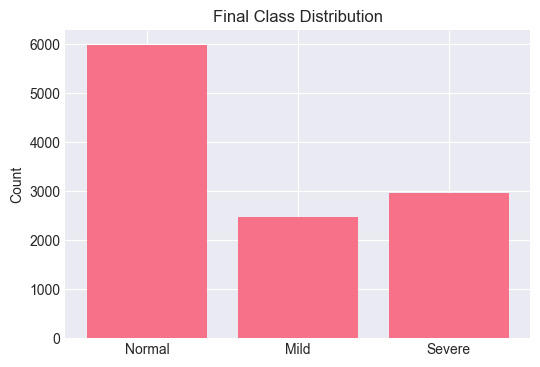

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.6813945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.541961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.8905448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..1.5768193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0474076].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.5245317].


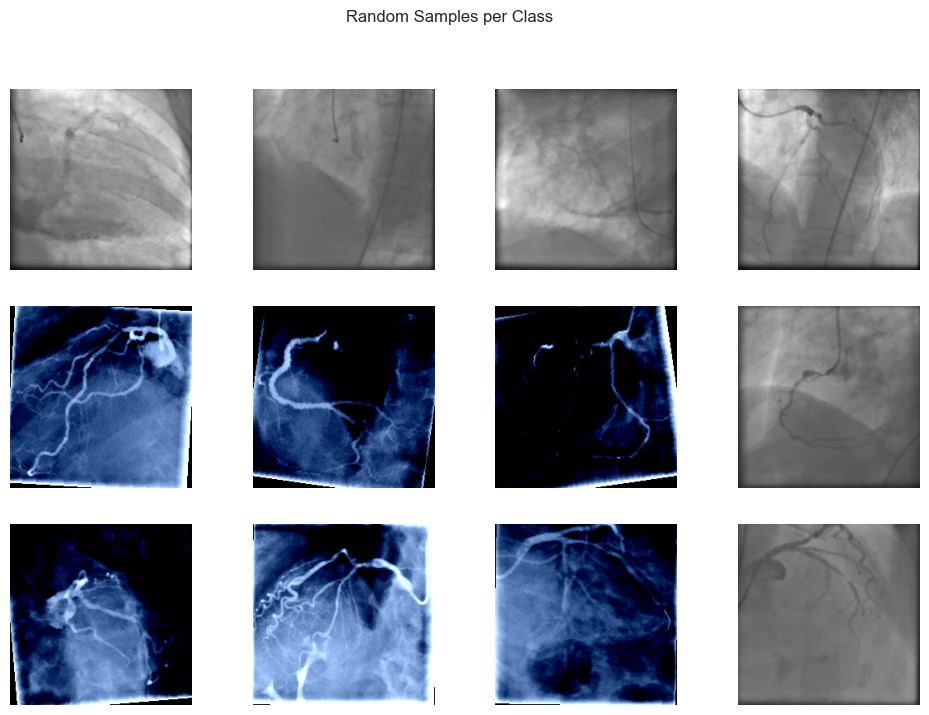


✓ CADICA preprocessing complete


In [11]:
print("\n" + "=" * 60)
print("CADICA DATASET PREPROCESSING")
print("=" * 60)

from collections import Counter
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import shutil

TARGET_NORMAL = 5984
BATCH_SIZE = 256

# ------------------------------------------------------------
# 🔴 CLEAR OLD SHARDS (WINDOWS SAFE)
# ------------------------------------------------------------
import glob, os

for split in ["train", "val", "test"]:
    split_dir = PROCESSED_CADICA_DIR / split
    if split_dir.exists():
        for f in glob.glob(str(split_dir / "*.npz")):
            try:
                os.remove(f)
            except PermissionError:
                print(f"⚠ Skipping locked file: {f}")

# ------------------------------------------------------------
# AUGMENTATION
# ------------------------------------------------------------
def augment_img(img):
    pil = Image.fromarray((img * 255).astype(np.uint8))
    aug = cnn_train_transform(pil)
    aug = aug.permute(1,2,0).numpy()
    return aug.astype("float32")

# ------------------------------------------------------------
# LOAD ALL IMAGES
# ------------------------------------------------------------
def load_all_images(selected_videos_dir):
    images, labels, pids = [], [], []

    for patient_dir in selected_videos_dir.iterdir():
        if not patient_dir.is_dir():
            continue

        pid = patient_dir.name.lower()

        for video_dir in patient_dir.iterdir():
            input_dir = video_dir/"input"
            gt_dir    = video_dir/"groundtruth"

            if not input_dir.exists():
                continue

            for img_file in input_dir.glob("*.png"):
                frame_id = img_file.stem.split("_")[-1]

                gt_file=None
                if gt_dir.exists():
                    for c in [gt_dir/f"{img_file.stem}.txt", gt_dir/f"{frame_id}.txt"]:
                        if c.exists():
                            gt_file=c
                            break

                severity = (
                    category_to_severity_label(parse_groundtruth_category(gt_file))
                    if gt_file else "Normal"
                )

                img = load_image(img_file, target_size=TARGET_SIZE)
                if img is None:
                    continue

                images.append(img)
                labels.append(LABEL_MAPPING[severity])
                pids.append(pid)

    return images, labels, pids

# ------------------------------------------------------------
# AUGMENT MINORITY
# ------------------------------------------------------------
def augment_minority(images, labels, pids):

    new_images, new_labels, new_pids = [], [], []

    for img,l,pid in zip(images,labels,pids):
        new_images.append(img)
        new_labels.append(l)
        new_pids.append(pid)

        if l == 1:  # Mild → 2x
            for _ in range(2):
                new_images.append(augment_img(img))
                new_labels.append(l)
                new_pids.append(pid)

        if l == 2:  # Severe → 1x
            new_images.append(augment_img(img))
            new_labels.append(l)
            new_pids.append(pid)

    return new_images, new_labels, new_pids

# ------------------------------------------------------------
# FINALIZE COUNTS
# ------------------------------------------------------------
def finalize_counts(images, labels, pids):

    normal, mild, severe = [], [], []

    for img,l,pid in zip(images,labels,pids):
        if l==0: normal.append((img,l,pid))
        elif l==1: mild.append((img,l,pid))
        else: severe.append((img,l,pid))

    random.shuffle(normal)
    normal = normal[:TARGET_NORMAL]

    combined = normal + mild + severe
    random.shuffle(combined)

    imgs = [x[0] for x in combined]
    lbls = [x[1] for x in combined]
    pids = [x[2] for x in combined]

    print("\nFINAL COUNTS:")
    print(Counter(lbls))

    return imgs, lbls, pids

# ------------------------------------------------------------
# SAVE SHARDS
# ------------------------------------------------------------
def save_shards(images, labels, out_dir, split):

    shard, batch_imgs, batch_lbls = 0, [], []

    for img,l in tqdm(list(zip(images,labels)), desc=f"{split} processing"):
        batch_imgs.append(img)
        batch_lbls.append(l)

        if len(batch_imgs)>=BATCH_SIZE:
            np.savez_compressed(
                out_dir/f"{split}_{shard}.npz",
                images=np.array(batch_imgs,np.float32),
                labels=np.array(batch_lbls,np.int32)
            )
            shard+=1
            batch_imgs, batch_lbls = [], []

    if batch_imgs:
        np.savez_compressed(
            out_dir/f"{split}_{shard}.npz",
            images=np.array(batch_imgs,np.float32),
            labels=np.array(batch_lbls,np.int32)
        )

# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------
images, labels, pids = load_all_images(CADICA_SELECTED_DIR)
images, labels, pids = augment_minority(images, labels, pids)
images, labels, pids = finalize_counts(images, labels, pids)

train, val, test = patient_stratified_split(
    images, labels, pids,
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO
)

print("\nSPLIT DISTRIBUTION:")
print("Train:", Counter(train[1]))
print("Val  :", Counter(val[1]))
print("Test :", Counter(test[1]))

save_shards(train[0], train[1], PROCESSED_CADICA_DIR/"train","train")
save_shards(val[0],   val[1],   PROCESSED_CADICA_DIR/"val","val")
save_shards(test[0],  test[1],  PROCESSED_CADICA_DIR/"test","test")

# ------------------------------------------------------------
# CLASS DISTRIBUTION PLOT
# ------------------------------------------------------------
all_lbls = np.array(labels)
counts = Counter(all_lbls)

plt.figure(figsize=(6,4))
names = ["Normal","Mild","Severe"]
vals = [counts[0],counts[1],counts[2]]

plt.bar(names, vals)
plt.title("Final Class Distribution")
plt.ylabel("Count")
plt.show()

# ------------------------------------------------------------
# RANDOM SAMPLES
# ------------------------------------------------------------
def show_random_samples(images, labels):

    class_imgs = {0:[],1:[],2:[]}

    for img,l in zip(images,labels):
        if len(class_imgs[l])<4:
            class_imgs[l].append(img)

    fig, axes = plt.subplots(3,4, figsize=(12,8))

    for row,l in enumerate([0,1,2]):
        for col in range(4):
            if col < len(class_imgs[l]):
                axes[row,col].imshow(class_imgs[l][col])
            axes[row,col].axis("off")

    plt.suptitle("Random Samples per Class")
    plt.show()

show_random_samples(images, labels)

print("\n✓ CADICA preprocessing complete")


## 7. NHANES DATASET PREPROCESSING


STEP 1 – LOADING NHANES XPT FILES
  ✓ BPQ_L         →   8501 rows, 4 cols
  ✓ DBQ_L         →  11933 rows, 1 cols
  ✓ DEMO_L        →  11933 rows, 4 cols
  ✓ DIQ_L         →  11744 rows, 2 cols
  ✓ DR1TOT_L      →   8860 rows, 4 cols
  ✓ DR2TOT_L      →   8860 rows, 4 cols
  ✓ GHB_L         →   7199 rows, 2 cols
  ✓ GLU_L         →   3996 rows, 2 cols
  ✓ HDL_L         →   8068 rows, 2 cols
  ✓ HSCRP_L       →   8727 rows, 2 cols
  ✓ INS_L         →   3996 rows, 2 cols
  ✓ PAQ_L         →   8153 rows, 2 cols
  ✓ SMQ_L         →   9015 rows, 3 cols
  ✓ TCHOL_L       →   8068 rows, 2 cols
  ✓ TRIGLY_L      →   3996 rows, 1 cols
  ✓ WHQ_L         →   8501 rows, 3 cols

STEP 2 – MERGING ON SEQN
Merged shape: (11933, 25)

STEP 3 – FEATURE ENGINEERING
  ✓ BMI computed
  ✓ AVG_SFAT computed
  ✓ AVG_SODI computed
  ✓ AVG_CHOL computed
  ✓ HOMA_IR computed
  ✓ NON_HDL computed

Shape after feature engineering: (11933, 24)

STEP 4 – MISSING VALUE HANDLING
  Dropped 5 high-missing columns
  Final

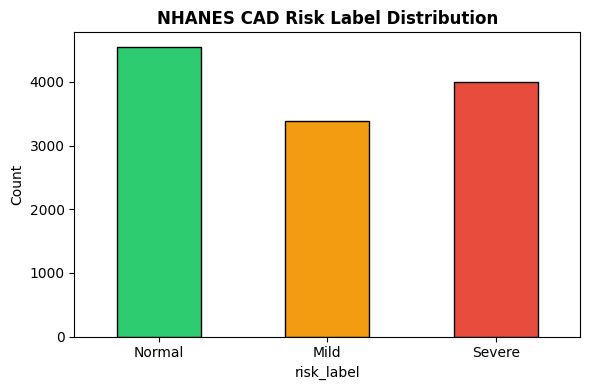

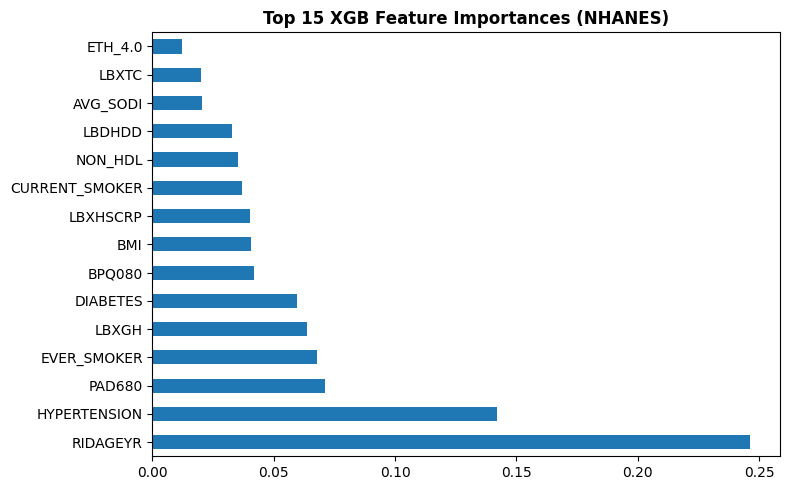

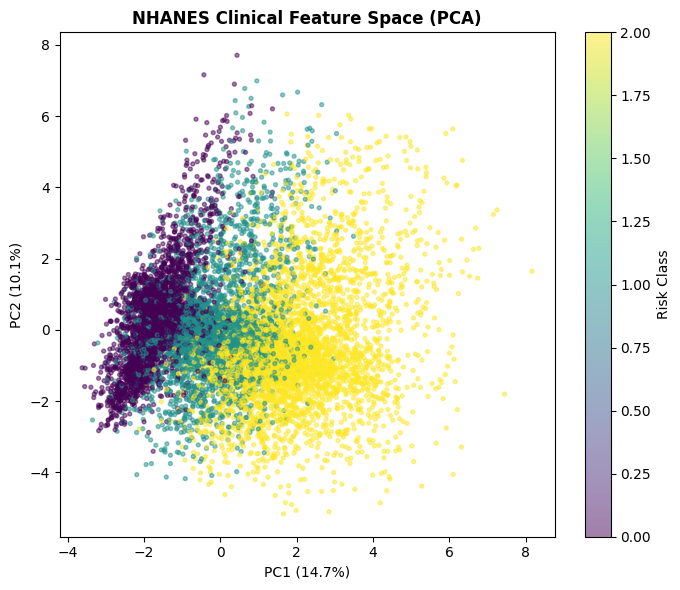

✓ All NHANES outputs saved to: processed_data\NHANES


In [3]:
import numpy as np
import pandas as pd
import pickle
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ============================================================
# PATHS  –  adjust BASE_DIR if needed
# ============================================================
BASE_DIR          = Path(".")
NHANES_DIR        = BASE_DIR / "NHANES"
PROCESSED_DIR     = BASE_DIR / "processed_data"
PROCESSED_NHANES_DIR = PROCESSED_DIR / "NHANES"
PROCESSED_NHANES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# STEP 1 – LOAD ALL XPT FILES
# ============================================================
print("=" * 60)
print("STEP 1 – LOADING NHANES XPT FILES")
print("=" * 60)

try:
    import pyreadstat
    XPT_AVAILABLE = True
except ImportError:
    raise ImportError("Install pyreadstat:  pip install pyreadstat")

# Every XPT file present in the screenshot
XPT_FILES = [
    "BPQ_L", "DBQ_L", "DEMO_L", "DIQ_L",
    "DR1TOT_L", "DR2TOT_L", "GHB_L", "GLU_L",
    "HDL_L", "HSCRP_L", "INS_L", "PAQ_L",
    "SMQ_L", "TCHOL_L", "TRIGLY_L", "WHQ_L"
]

# ── Exact variable names confirmed from NHANES codebooks ──
VARIABLES_TO_KEEP = {
    "DEMO_L"   : ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"],
    "BPQ_L"    : ["SEQN", "BPQ020", "BPQ030", "BPQ080"],        # hypertension, BP meds, cholesterol meds
    "DIQ_L"    : ["SEQN", "DIQ010"],                             # diabetes
    "SMQ_L"    : ["SEQN", "SMQ020", "SMQ040"],                  # ever/current smoker
    "DBQ_L"    : ["SEQN", "DBD895"],                            # meals not home-prepared (diet proxy)
    "TCHOL_L"  : ["SEQN", "LBXTC"],                            # total cholesterol
    "HDL_L"    : ["SEQN", "LBDHDD"],                            # HDL cholesterol
    "TRIGLY_L" : ["SEQN", "LBXTR"],                            # triglycerides
    "GLU_L"    : ["SEQN", "LBXGLU"],                           # fasting glucose
    "GHB_L"    : ["SEQN", "LBXGH"],                            # HbA1c
    "HSCRP_L"  : ["SEQN", "LBXHSCRP"],                        # high-sensitivity CRP
    "INS_L"    : ["SEQN", "LBXIN"],                            # fasting insulin (HOMA-IR proxy)
    "WHQ_L"    : ["SEQN", "WHD010", "WHD020"],                 # weight, height → BMI
    "PAQ_L"    : ["SEQN", "PAQ605", "PAQ620", "PAD680"],       # vigorous/mod activity, sedentary min
    "DR1TOT_L" : ["SEQN", "DR1TSFAT", "DR1TSODI", "DR1TCHOL"],# dietary sat-fat, sodium, cholesterol
    "DR2TOT_L" : ["SEQN", "DR2TSFAT", "DR2TSODI", "DR2TCHOL"],# day-2 dietary recall
}

frames = {}
for xpt_name in XPT_FILES:
    xpt_path = NHANES_DIR / f"{xpt_name}.xpt"
    if not xpt_path.exists():
        print(f"  ⚠  {xpt_name}.xpt not found – skipping")
        continue

    # ---- FIXED LOADER ----
    try:
        df_raw, _ = pyreadstat.read_xport(str(xpt_path), encoding="latin1")
    except:
        df_raw, _ = pyreadstat.read_xport(str(xpt_path))

    df_raw.columns = df_raw.columns.str.upper()

    if xpt_name in VARIABLES_TO_KEEP:
        keep = [c for c in VARIABLES_TO_KEEP[xpt_name] if c in df_raw.columns]
        df_raw = df_raw[keep]

    frames[xpt_name] = df_raw
    print(f"  ✓ {xpt_name:12s}  →  {df_raw.shape[0]:5d} rows, {df_raw.shape[1]} cols")

# ============================================================
# STEP 2 – MERGE ON SEQN
# ============================================================
print("\n" + "=" * 60)
print("STEP 2 – MERGING ON SEQN")
print("=" * 60)

merged = frames["DEMO_L"].copy()

for name, df in frames.items():
    if name == "DEMO_L":
        continue
    if "SEQN" not in df.columns:
        continue
    merged = merged.merge(df, on="SEQN", how="left")

print(f"Merged shape: {merged.shape}")

# ============================================================
# STEP 3 – FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 60)
print("STEP 3 – FEATURE ENGINEERING")
print("=" * 60)

# ── BMI ──
if {"WHD010", "WHD020"}.issubset(merged.columns):
    # WHD010 = weight (kg), WHD020 = height (cm)
    # NHANES sometimes stores weight in lbs/kg depending on cycle;
    # L-cycle uses kg for WHD010 and cm for WHD020
    ht_m = merged["WHD020"].replace([7777, 9999], np.nan) / 100.0
    wt_kg = merged["WHD010"].replace([7777, 9999], np.nan)
    merged["BMI"] = wt_kg / (ht_m ** 2)
    merged["BMI"] = merged["BMI"].clip(10, 80)          # physiological range
    print("  ✓ BMI computed")

# ── Average dietary intake (Day1 + Day2) ──
for nutrient in ["SFAT", "SODI", "CHOL"]:
    c1, c2 = f"DR1T{nutrient}", f"DR2T{nutrient}"
    if c1 in merged.columns and c2 in merged.columns:
        merged[f"AVG_{nutrient}"] = merged[[c1, c2]].mean(axis=1)
        merged.drop(columns=[c1, c2], inplace=True)
    elif c1 in merged.columns:
        merged.rename(columns={c1: f"AVG_{nutrient}"}, inplace=True)
    print(f"  ✓ AVG_{nutrient} computed")

# ── HOMA-IR proxy (glucose × insulin / 405) ──
if {"LBXGLU", "LBXIN"}.issubset(merged.columns):
    merged["HOMA_IR"] = (merged["LBXGLU"] * merged["LBXIN"]) / 405.0
    print("  ✓ HOMA_IR computed")

# ── Non-HDL cholesterol ──
if {"LBXTC", "LBDHDD"}.issubset(merged.columns):
    merged["NON_HDL"] = merged["LBXTC"] - merged["LBDHDD"]
    print("  ✓ NON_HDL computed")

# ── Triglyceride/HDL ratio (insulin resistance marker) ──
if {"LBXTR", "LBDHDD"}.issubset(merged.columns):
    merged["TG_HDL_RATIO"] = merged["LBXTR"] / (merged["LBDHDD"] + 1e-6)
    print("  ✓ TG_HDL_RATIO computed")

# ── Encode smoker status (SMQ040: 1=daily, 2=somedays, 3=not at all) ──
if "SMQ040" in merged.columns:
    merged["CURRENT_SMOKER"] = (merged["SMQ040"].isin([1, 2])).astype(int)

# ── Drop raw weight/height columns (subsumed into BMI) ──
merged.drop(columns=[c for c in ["WHD010", "WHD020"] if c in merged.columns],
            inplace=True, errors="ignore")

print(f"\nShape after feature engineering: {merged.shape}")

# ============================================================
# STEP 4 – MISSING VALUE HANDLING
# ============================================================
print("\n" + "=" * 60)
print("STEP 4 – MISSING VALUE HANDLING")
print("=" * 60)

# Replace NHANES sentinel codes
SENTINEL_VALUES = [7777, 9999, 77777, 99999]
merged.replace(SENTINEL_VALUES, np.nan, inplace=True)

# Drop columns with >60% missing
miss_pct = merged.isnull().mean() * 100
drop_cols = miss_pct[miss_pct > 60].index.tolist()
drop_cols = [c for c in drop_cols if c != "SEQN"]
merged.drop(columns=drop_cols, inplace=True, errors="ignore")
print(f"  Dropped {len(drop_cols)} high-missing columns")

# Impute remaining
num_cols = [c for c in merged.select_dtypes(include=[np.number]).columns
            if c != "SEQN"]
merged[num_cols] = SimpleImputer(strategy="median").fit_transform(merged[num_cols])

print(f"  Final shape: {merged.shape}")

# ============================================================
# STEP 5 – CATEGORICAL ENCODING
# ============================================================
print("\n" + "=" * 60)
print("STEP 5 – CATEGORICAL ENCODING")
print("=" * 60)

# Binary encode gender (1=Male, 2=Female → 0/1)
if "RIAGENDR" in merged.columns:
    merged["FEMALE"] = (merged["RIAGENDR"] == 2).astype(int)
    merged.drop(columns=["RIAGENDR"], inplace=True)

# Binary encode diabetes (1=Yes, 2=No, 3=Borderline → 0/1/0.5)
if "DIQ010" in merged.columns:
    merged["DIABETES"] = merged["DIQ010"].map({1: 1, 3: 0.5, 2: 0}).fillna(0)
    merged.drop(columns=["DIQ010"], inplace=True)

# Binary hypertension
if "BPQ020" in merged.columns:
    merged["HYPERTENSION"] = (merged["BPQ020"] == 1).astype(int)
    merged.drop(columns=["BPQ020"], inplace=True)

# Smoker (ever)
if "SMQ020" in merged.columns:
    merged["EVER_SMOKER"] = (merged["SMQ020"] == 1).astype(int)
    merged.drop(columns=["SMQ020"], inplace=True)

# Ethnicity one-hot (RIDRETH3)
if "RIDRETH3" in merged.columns:
    merged = pd.get_dummies(merged, columns=["RIDRETH3"], prefix="ETH", drop_first=True)

print(f"  Shape after encoding: {merged.shape}")

# ============================================================
# STEP 6 – FRAMINGHAM-STYLE CAD RISK SCORE
# ============================================================
# This creates a MEDICALLY GROUNDED label (not synthetic qcut)
# Based on published CAD risk factor weights
print("\n" + "=" * 60)
print("STEP 6 – FRAMINGHAM-STYLE CAD RISK LABEL")
print("=" * 60)

def framingham_risk_score(row):
    score = 0.0

    # Age contribution (major risk factor)
    age = row.get("RIDAGEYR", 50)
    if age < 40:   score += 0
    elif age < 50: score += 1
    elif age < 60: score += 2
    elif age < 70: score += 3
    else:          score += 4

    # Total cholesterol
    tc = row.get("LBXTC", 200)
    if tc < 160:   score += 0
    elif tc < 200: score += 1
    elif tc < 240: score += 2
    elif tc < 280: score += 3
    else:          score += 4

    # HDL – protective (inverse)
    hdl = row.get("LBDHDD", 50)
    if hdl >= 60:  score -= 1
    elif hdl >= 50: score += 0
    elif hdl >= 40: score += 1
    else:           score += 2

    # Hypertension / BP meds
    score += row.get("HYPERTENSION", 0) * 2
    score += row.get("BPQ030", 0) * 1   # on BP meds

    # Smoking
    score += row.get("EVER_SMOKER", 0) * 1
    score += row.get("CURRENT_SMOKER", 0) * 1  # extra if current

    # Diabetes
    score += row.get("DIABETES", 0) * 2

    # HbA1c (glycaemic control)
    hba1c = row.get("LBXGH", 5.5)
    if hba1c >= 6.5: score += 2
    elif hba1c >= 5.7: score += 1

    # CRP (inflammation)
    crp = row.get("LBXHSCRP", 1.0)
    if crp >= 3.0:  score += 2
    elif crp >= 1.0: score += 1

    # BMI
    bmi = row.get("BMI", 25)
    if bmi >= 35:   score += 2
    elif bmi >= 30: score += 1

    # TG/HDL ratio (insulin resistance)
    tg_hdl = row.get("TG_HDL_RATIO", 2.0)
    if tg_hdl >= 4.0: score += 2
    elif tg_hdl >= 2.5: score += 1

    # Physical inactivity (PAD680 = sedentary min/day)
    sed = row.get("PAD680", 300)
    if sed >= 480: score += 2      # 8+ hours sedentary
    elif sed >= 360: score += 1

    # High dietary sodium
    sodi = row.get("AVG_SODI", 2300)
    if sodi >= 3500: score += 1

    return score

print("  Computing Framingham-style risk scores ...")
risk_scores = merged.apply(framingham_risk_score, axis=1)

# Convert to 3 classes using clinical thresholds
# Low (<4) = Normal (0), Moderate (4-8) = Mild (1), High (>8) = Severe (2)
def score_to_class(s):
    if s < 4:  return 0
    if s < 8:  return 1
    return 2

merged["risk_label"] = risk_scores.apply(score_to_class)

dist = merged["risk_label"].value_counts().sort_index()
print(f"\n  Risk label distribution:")
for cls, cnt in dist.items():
    name = {0: "Normal/Low", 1: "Mild/Moderate", 2: "Severe/High"}[cls]
    print(f"    Class {cls} ({name}): {cnt} ({cnt/len(merged)*100:.1f}%)")

# ============================================================
# STEP 7 – SCALING
# ============================================================
print("\n" + "=" * 60)
print("STEP 7 – SCALING")
print("=" * 60)

feature_cols = [c for c in merged.columns if c not in ["SEQN", "risk_label"]]

# convert bool → int
for c in feature_cols:
    if merged[c].dtype == bool:
        merged[c] = merged[c].astype(int)

# Clip extreme outliers before scaling
for col in feature_cols:
    q1, q99 = merged[col].quantile(0.01), merged[col].quantile(0.99)
    merged[col] = merged[col].clip(q1, q99)

scaler = StandardScaler()
merged[feature_cols] = scaler.fit_transform(merged[feature_cols])

# Save scaler with feature list (new format)
scaler_payload = {
    "scaler": scaler,
    "feature_cols": feature_cols
}
with open(PROCESSED_NHANES_DIR / "nhanes_scaler.pkl", "wb") as f:
    pickle.dump(scaler_payload, f)
print(f"  ✓ Scaler saved  ({len(feature_cols)} features)")

# ============================================================
# STEP 8 – TRAIN XGB CLINICAL MODEL
# ============================================================
print("\n" + "=" * 60)
print("STEP 8 – TRAINING XGB CLINICAL MODEL")
print("=" * 60)

X = merged[feature_cols].values
y = merged["risk_label"].values

X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

nhanes_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

nhanes_model.fit(
    X_train_n, y_train_n,
    eval_set=[(X_val_n, y_val_n)],
    verbose=50
)

val_preds = nhanes_model.predict(X_val_n)
val_acc   = (val_preds == y_val_n).mean()
print(f"\n  XGB Validation Accuracy : {val_acc:.4f}")
print("\n  Classification Report:")
print(classification_report(y_val_n, val_preds,
                            target_names=["Normal", "Mild", "Severe"]))

# Save model
with open(PROCESSED_NHANES_DIR / "nhanes_xgb.pkl", "wb") as f:
    pickle.dump(nhanes_model, f)
print("  ✓ XGB model saved")

# ============================================================
# STEP 9 – SAVE CLEAN CSV
# ============================================================
output_path = PROCESSED_NHANES_DIR / "NHANES_clean.csv"
merged.to_csv(output_path, index=False)

print("\n" + "=" * 60)
print("NHANES PREPROCESSING COMPLETE")
print("=" * 60)
print(f"  Samples  : {len(merged)}")
print(f"  Features : {len(feature_cols)}")
print(f"  Saved →  {output_path}")

# ============================================================
# STEP 10 – VISUALISATIONS
# ============================================================
print("\nGenerating visualisations ...")

# ── Risk label distribution ──
fig, ax = plt.subplots(figsize=(6, 4))
dist.plot(kind="bar", ax=ax, color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="black")
ax.set_xticklabels(["Normal", "Mild", "Severe"], rotation=0)
ax.set_title("NHANES CAD Risk Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(PROCESSED_NHANES_DIR / "nhanes_risk_distribution.png", dpi=150)
plt.show()

# ── Feature importance ──
fi = pd.Series(nhanes_model.feature_importances_, index=feature_cols)
top15 = fi.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.plot(kind="barh", ax=ax)
ax.set_title("Top 15 XGB Feature Importances (NHANES)", fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_NHANES_DIR / "nhanes_feature_importance.png", dpi=150)
plt.show()

# ── PCA ──
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(merged[feature_cols].values)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(pca_proj[:, 0], pca_proj[:, 1],
                     c=y, cmap="viridis", s=8, alpha=0.5)
plt.colorbar(scatter, ax=ax, label="Risk Class")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("NHANES Clinical Feature Space (PCA)", fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_NHANES_DIR / "nhanes_pca.png", dpi=150)
plt.show()

print("✓ All NHANES outputs saved to:", PROCESSED_NHANES_DIR)


In [2]:
import pandas as pd

# Load NHANES CSV
df = pd.read_csv("processed_data/NHANES/NHANES_clean.csv")

# Print all feature names
print("Features in NHANES dataset:\n")
for col in df.columns:
    print(col)

# Optional: total number of features
print("\nTotal number of features:", len(df.columns))

import pandas as pd

# Load the cleaned NHANES dataset
df = pd.read_csv("processed_data/NHANES/NHANES_clean.csv")

# Print first 10 columns
print("First 10 columns:\n")
print(df.iloc[:, :10].head())



Features in NHANES dataset:

SEQN
RIDAGEYR
BPQ080
LBXGH
LBDHDD
LBXHSCRP
PAD680
LBXTC
BMI
AVG_SFAT
AVG_SODI
AVG_CHOL
NON_HDL
CURRENT_SMOKER
FEMALE
DIABETES
HYPERTENSION
EVER_SMOKER
ETH_2.0
ETH_3.0
ETH_4.0
ETH_6.0
ETH_7.0
risk_label

Total number of features: 24
First 10 columns:

       SEQN  RIDAGEYR    BPQ080     LBXGH    LBDHDD  LBXHSCRP    PAD680  \
0  130378.0  0.182890  0.591900 -0.000614 -0.801226 -0.193447  0.112155   
1  130379.0  1.081295  0.591900 -0.000614  0.677650 -0.114126  0.819560   
2  130380.0  0.221951 -1.689476  0.922313 -0.406859  1.024923 -0.595251   
3  130381.0 -1.301432  0.591900 -0.154435 -0.111084 -0.298151 -0.241548   
4  130382.0 -1.418615  0.591900 -0.154435 -0.111084 -0.298151 -0.241548   

      LBXTC       BMI  AVG_SFAT  
0  2.743563 -0.453806 -1.022780  
1  1.113759 -1.008416 -0.803815  
2  0.233664  0.291999 -0.680991  
3 -0.059701 -0.156250 -1.078793  
4 -0.059701 -0.156250 -1.337834  
